In [28]:
!pip install matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 5.3 MB/s  0:00:01 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 5.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 5.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m6/8 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [29]:
# ── Run this cell FIRST ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# For Jupyter notebooks — render plots inline
%matplotlib inline

print("✅ All imports successful!")

✅ All imports successful!


# Read in the data

In [1]:
import pandas as pd

df = pd.read_parquet("data/flights_2018_2024_v2.parquet")

df.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Flight_Number_Reporting_Airline,Origin,Dest,CRSDepTime,DepTimeBlk,CRSArrTime,ArrDel15,CRSElapsedTime,Distance,DistanceGroup
0,2018,1,1,1,1,2018-01-01,WN,1491.0,ABQ,BWI,730,0700-0759,1310,0.0,220.0,1670.0,7
1,2018,1,1,1,1,2018-01-01,UA,2102.0,IAH,LAS,1420,1400-1459,1547,0.0,207.0,1222.0,5
2,2018,1,1,1,1,2018-01-01,UA,2101.0,IAH,SFO,2113,2100-2159,2340,0.0,267.0,1635.0,7
3,2018,1,1,1,1,2018-01-01,UA,2100.0,IAH,FLL,2010,2000-2059,2337,0.0,147.0,966.0,4
4,2018,1,1,1,1,2018-01-01,UA,2099.0,SAN,IAH,1340,1300-1359,1848,0.0,188.0,1303.0,6


In [7]:
df.shape      # total rows and columns

(45968068, 17)

In [8]:
df["Year"].unique()   # years present

array([2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [14]:
summary = df.groupby("Year").size().to_frame("rows")
summary["columns"] = df.shape[1]

print(summary)

         rows  columns
Year                  
2018  7206195       17
2019  7422037       17
2020  4688354       17
2021  5995397       17
2022  6729125       17
2023  6847899       17
2024  7079061       17


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45968068 entries, 0 to 45968067
Data columns (total 17 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   Year                             int64  
 1   Quarter                          int64  
 2   Month                            int64  
 3   DayofMonth                       int64  
 4   DayOfWeek                        int64  
 5   FlightDate                       object 
 6   Reporting_Airline                object 
 7   Flight_Number_Reporting_Airline  float64
 8   Origin                           object 
 9   Dest                             object 
 10  CRSDepTime                       int64  
 11  DepTimeBlk                       object 
 12  CRSArrTime                       int64  
 13  ArrDel15                         float64
 14  CRSElapsedTime                   float64
 15  Distance                         float64
 16  DistanceGroup                    int64  
dtypes: flo

## Convert columns to other data types

In [21]:
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

cat_cols = ["Reporting_Airline", "Origin", "Dest", "DepTimeBlk"]
df[cat_cols] = df[cat_cols].astype("category")

df["Flight_Number_Reporting_Airline"] = df["Flight_Number_Reporting_Airline"].astype("string")

df["ArrDel15"] = df["ArrDel15"].astype("Int64")

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45968068 entries, 0 to 45968067
Data columns (total 17 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   Year                             int64         
 1   Quarter                          int64         
 2   Month                            int64         
 3   DayofMonth                       int64         
 4   DayOfWeek                        int64         
 5   FlightDate                       datetime64[ns]
 6   Reporting_Airline                category      
 7   Flight_Number_Reporting_Airline  string        
 8   Origin                           category      
 9   Dest                             category      
 10  CRSDepTime                       int64         
 11  DepTimeBlk                       category      
 12  CRSArrTime                       int64         
 13  ArrDel15                         Int64         
 14  CRSElapsedTime                  

## Missingness Analysis

In [ ]:
import pandas as pd
import numpy as np

def missing_value_analysis(df: pd.DataFrame, show_all: bool = False) -> pd.DataFrame:
    # --- Basic counts ---
    total_rows = len(df)
    missing_count = df.isnull().sum()
    missing_pct = (missing_count / total_rows) * 100
    present_count = df.notnull().sum()
    dtype_series = df.dtypes

    # --- Build summary table ---
    summary = pd.DataFrame({
        'dtype': dtype_series,
        'total_rows': total_rows,
        'missing_count': missing_count,
        'missing_pct': missing_pct.round(2),
        'present_count': present_count,
        'unique_values': df.nunique()
    }).sort_values('missing_pct', ascending=False)

    if not show_all:
        summary = summary[summary['missing_count'] > 0]

    # --- Print high-level overview ---
    total_cells = np.prod(df.shape)
    total_missing = df.isnull().sum().sum()
    cols_with_missing = (missing_count > 0).sum()

    print("=" * 55)
    print("       MISSING VALUE ANALYSIS REPORT")
    print("=" * 55)
    print(f"  📐 Shape              : {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"  🔢 Total cells        : {total_cells:,}")
    print(f"  ❌ Total missing      : {total_missing:,} ({total_missing/total_cells*100:.2f}%)")
    print(f"  📋 Columns w/ missing : {cols_with_missing} / {df.shape[1]}")
    print(f"  ✅ Complete rows       : {df.dropna().shape[0]:,} / {df.shape[0]:,}")
    print("=" * 55)

    return summary

def missing_pattern_analysis(df: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    """
    Identify co-occurrence patterns of missing values.

    Shows which combinations of columns tend to be missing together.
    """
    # Encode each row's missing pattern as a string signature
    pattern = df.isnull().astype(int)
    cols = df.columns.tolist()

    pattern['_signature'] = pattern.apply(
        lambda row: ' | '.join([c for c, v in zip(cols, row) if v == 1]) or '✅ No missing',
        axis=1
    )

    pattern_counts = (
        pattern['_signature']
        .value_counts()
        .head(top_n)
        .reset_index()
    )
    pattern_counts.columns = ['missing_columns_pattern', 'row_count']
    pattern_counts['pct_of_rows'] = (pattern_counts['row_count'] / len(df) * 100).round(2)

    print(f"\n🔍 Top {top_n} Missing Value Patterns:\n")
    return pattern_counts

In [25]:
# Run the main analysis
summary = missing_value_analysis(df, show_all=True)
print(summary)

# View co-occurrence patterns
patterns = missing_pattern_analysis(df)
print(patterns)

       MISSING VALUE ANALYSIS REPORT
  📐 Shape              : 45968068 rows × 17 columns
  🔢 Total cells        : 781,457,156
  ❌ Total missing      : 1,110,074 (0.14%)
  📋 Columns w/ missing : 3 / 17
  ✅ Complete rows       : 44,858,151 / 45,968,068
                                          dtype  total_rows  missing_count  \
ArrDel15                                  Int64    45968068        1109916   
Year                                      int64    45968068              0   
Dest                                   category    45968068              0   
Distance                                float64    45968068              0   
CRSElapsedTime                          float64    45968068            157   
CRSArrTime                                int64    45968068              0   
DepTimeBlk                             category    45968068              0   
CRSDepTime                                int64    45968068              0   
Origin                                 category

## Distribution of ArrDelay15

In [32]:
# Summary statistics
print("\n📊 ArrDel15 Summary Statistics")
print(df["ArrDel15"].describe().round(2))


📊 ArrDel15 Summary Statistics
count    44858152.0
mean           0.19
std            0.39
min             0.0
25%             0.0
50%             0.0
75%             0.0
max             1.0
Name: ArrDel15, dtype: Float64


In [36]:
# ══════════════════════════════════════════════════════════════════════
# Arrival Delay Summary Statistics by Year
# ══════════════════════════════════════════════════════════════════════

yearly_stats = (
    df.groupby("Year")["ArrDel15"]
      .agg(
          Count    = "count",
          Mean     = "mean"
      )
      .round(2)
)

# ── Pretty Print ──────────────────────────────────────────────────────
print("=" * 90)
print("✈️  ARRIVAL DELAY SUMMARY STATISTICS BY YEAR")
print("=" * 90)
print(yearly_stats.to_string())
print("-" * 90)

# ── Overall across all years ──────────────────────────────────────────
print("\n📌 OVERALL (All Years Combined)")
print(f"   Count       : {df['ArrDel15'].count():,}")
print(f"   Mean        : {df['ArrDel15'].mean():.2f}")

✈️  ARRIVAL DELAY SUMMARY STATISTICS BY YEAR
        Count  Mean
Year               
2018  7071464  0.19
2019  7268232  0.19
2020  4399575   0.1
2021  5878219  0.17
2022  6532012  0.21
2023  6743403  0.21
2024  6965247  0.21
------------------------------------------------------------------------------------------

📌 OVERALL (All Years Combined)
   Count       : 44,858,152
   Mean        : 0.19


In [37]:
# ══════════════════════════════════════════════════════════════════════
# Class Imbalance Ratio by Year
# ══════════════════════════════════════════════════════════════════════

imbalance = (
    df.groupby("Year")["ArrDel15"]
      .agg(
          Total_Flights = "count",
          Delayed       = "sum",                              # class 1
      )
      .assign(
          On_Time         = lambda x: x["Total_Flights"] - x["Delayed"],   # class 0
          Delayed_Pct     = lambda x: (x["Delayed"] / x["Total_Flights"] * 100).round(2),
          On_Time_Pct     = lambda x: (x["On_Time"] / x["Total_Flights"] * 100).round(2),
          Imbalance_Ratio = lambda x: (x["On_Time"] / x["Delayed"]).round(2)  # majority / minority
      )
)

# ── Pretty Print ──────────────────────────────────────────────────────
print("=" * 95)
print("✈️  CLASS IMBALANCE RATIO BY YEAR  (On-Time vs Delayed ≥15 min)")
print("=" * 95)
print(imbalance.to_string())
print("-" * 95)

# ── Overall ───────────────────────────────────────────────────────────
total    = len(df)
delayed  = df["ArrDel15"].sum()
on_time  = total - delayed
ratio    = round(on_time / delayed, 2)

print(f"\n📌 OVERALL")
print(f"   Total Flights    : {total:,}")
print(f"   On-Time (class 0): {on_time:,}  ({on_time/total*100:.2f}%)")
print(f"   Delayed (class 1): {delayed:,}  ({delayed/total*100:.2f}%)")
print(f"   Imbalance Ratio  : {ratio} : 1")

✈️  CLASS IMBALANCE RATIO BY YEAR  (On-Time vs Delayed ≥15 min)
      Total_Flights  Delayed  On_Time  Delayed_Pct  On_Time_Pct  Imbalance_Ratio
Year                                                                            
2018        7071464  1352165  5719299        19.12        80.88             4.23
2019        7268232  1389253  5878979        19.11        80.89             4.23
2020        4399575   431921  3967654         9.82        90.18             9.19
2021        5878219  1010332  4867887        17.19        82.81             4.82
2022        6532012  1376798  5155214        21.08        78.92             3.74
2023        6743403  1386699  5356704        20.56        79.44             3.86
2024        6965247  1449966  5515281        20.82        79.18              3.8
-----------------------------------------------------------------------------------------------

📌 OVERALL
   Total Flights    : 45,968,068
   On-Time (class 0): 37,570,934  (81.73%)
   Delayed (class 1): 8,

Delayed flights constitute ~18/.27% of the data, with imbalance increasing during COVID. Several post‑arrival fields are excluded to prevent leakage.

   Year  Pct_Delayed
0  2018        19.12
1  2019        19.11
2  2020         9.82
3  2021        17.19
4  2022        21.08
5  2023        20.56
6  2024        20.82


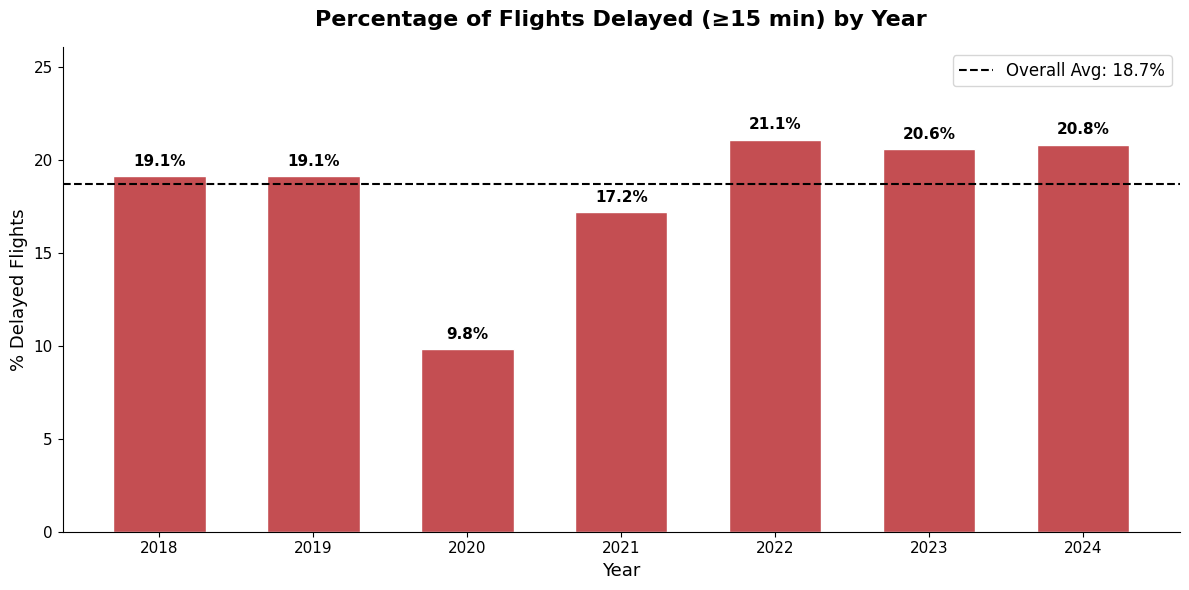

In [39]:
# ── Calculate % Delayed by Year ──────────────────────────────────────
delay_pct = (
    df.groupby("Year")["ArrDel15"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
      .rename(columns={"ArrDel15": "Pct_Delayed"})
)

print(delay_pct)

# ══════════════════════════════════════════════════════════════════════
# Bar Chart
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    delay_pct["Year"].astype(str),
    delay_pct["Pct_Delayed"],
    color="#c44e52",
    edgecolor="white",
    width=0.6
)

# ── Add value labels on top of each bar ──────────────────────────────
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.4,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# ── Add a horizontal reference line at the overall average ───────────
overall_avg = df["ArrDel15"].mean() * 100
ax.axhline(
    y=overall_avg,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall Avg: {overall_avg:.1f}%"
)

# ── Formatting ───────────────────────────────────────────────────────
ax.set_title("Percentage of Flights Delayed (≥15 min) by Year",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("% Delayed Flights", fontsize=13)
ax.set_ylim(0, delay_pct["Pct_Delayed"].max() + 5)
ax.legend(fontsize=12, loc="upper right")
ax.tick_params(axis="both", labelsize=11)

# Remove top & right spines for a cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("delay_pct_by_year.png", dpi=150, bbox_inches="tight")
plt.show()
